# HARMONY-X Llama-3.1-8B Experiment Analysis

Phân tích kết quả thí nghiệm reverse engineer defense layer của Llama-3.1-8B.

In [6]:
import json
import os
from pathlib import Path

OUTPUTS_DIR = Path("outputs")

# Load outputs
def load_json(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

program = load_json(OUTPUTS_DIR / "final_program.json")
theory = load_json(OUTPUTS_DIR / "final_theory.json")
interventions = load_json(OUTPUTS_DIR / "interventions_history.json")
summary = load_json(OUTPUTS_DIR / "hypotheses_history.json")

print("Outputs loaded successfully")
if summary:
    print(f"  Success: {summary.get('success')}")
    print(f"  Best accuracy: {summary.get('best_accuracy')}")
    print(f"  Interventions: {summary.get('total_interventions')}")
    print(f"  Iterations: {summary.get('total_iterations')}")

Outputs loaded successfully
  Success: True
  Best accuracy: 0.3
  Interventions: 1
  Iterations: 1


## 1. Final Program (AST)

In [7]:
if program:
    print("Final Defense Program (AST):")
    print(json.dumps(program, indent=2))
else:
    print("No final program found")

Final Defense Program (AST):
{
  "id": "dfp_91f11d6edc31",
  "name": "synth_prog_1780807202972",
  "version": 1,
  "confidence": 0.3,
  "provenance": [
    "exp:vicuna_test_001_run",
    "ep:ep_586e1c500279",
    "ep:ep_c801a3f56107",
    "ep:ep_44345a01a600",
    "ep:ep_95f8a24b733d",
    "ep:ep_7fcbc9a8b557"
  ],
  "created_at": 1780807214.01659,
  "updated_at": 1780807214.01659,
  "metadata": {
    "status": "draft"
  },
  "program": {
    "id": "dfp_91f11d6edc31",
    "version_id": "1.0",
    "created_at": 1780807214.4231172,
    "deprecated_at": null,
    "metadata": {},
    "root": {
      "type": "IfThenElseNode",
      "condition": {
        "type": "PredicateNode",
        "primitive": {
          "name": "contains_word",
          "parameters": {
            "word": "how",
            "case_sensitive": false
          },
          "type": "ContainsWordPredicate",
          "input_type": "String",
          "output_type": "Boolean",
          "version_id": "1.0",
          "cr

## 2. Final Theory

In [8]:
if theory:
    print("Final Theory:")
    if isinstance(theory, dict):
        print(json.dumps(theory, indent=2))
    else:
        print(theory)
else:
    print("No final theory found")

Final Theory:
[{'id': 'thr_58e55e10e360', 'pattern': 'IF contains_word({"word": "bomb", "case_sensitive": false}) THEN REFUSE', 'conditions': {'campaign_id': 'single_test', 'experiment_id': 'single_test_run', 'accuracy': 1.0, 'verified': True, 'model_family': 'unknown', 'complexity': 2}, 'confidence': 0.0, 'provenance': ['exp:single_test_run', 'ep:seed_0', 'ep:seed_1', 'ep:seed_2', 'ep:seed_3', 'ep:seed_4'], 'version': 1, 'created_at': 1780765042.01465, 'updated_at': 1780765042.01465, 'metadata': {'program_id': 'prog_1780765041854', 'node_count': 2, 'depth': 2, 'then_outcome': 1, 'else_outcome': 0}}, {'id': 'thr_5b53c8d8544a', 'pattern': 'IF contains_word({"word": "how", "case_sensitive": false}) THEN REFUSE', 'conditions': {'campaign_id': 'vicuna_test_001', 'experiment_id': 'vicuna_test_001_run', 'accuracy': 0.3, 'verified': False, 'model_family': 'unknown', 'complexity': 2}, 'confidence': 0.0, 'provenance': ['exp:vicuna_test_001_run', 'ep:ep_586e1c500279', 'ep:ep_c801a3f56107', 'ep:e

## 3. Biểu đồ Accuracy theo Can thiệp

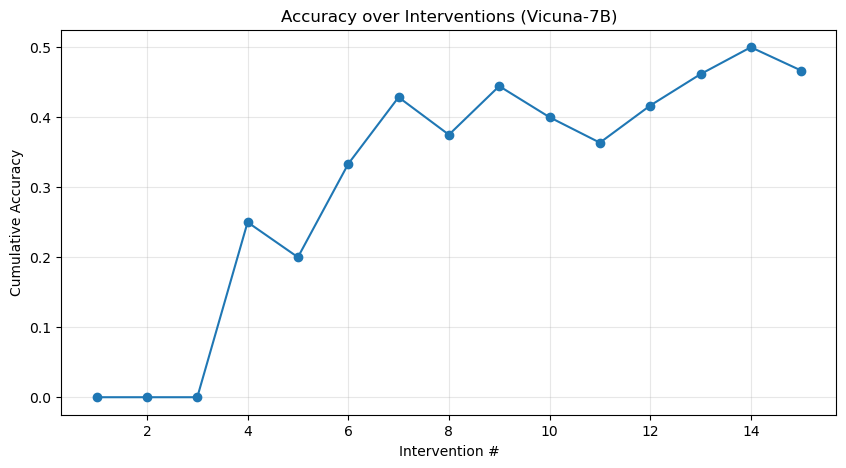

REFUSE: 8, ACCEPT: 7


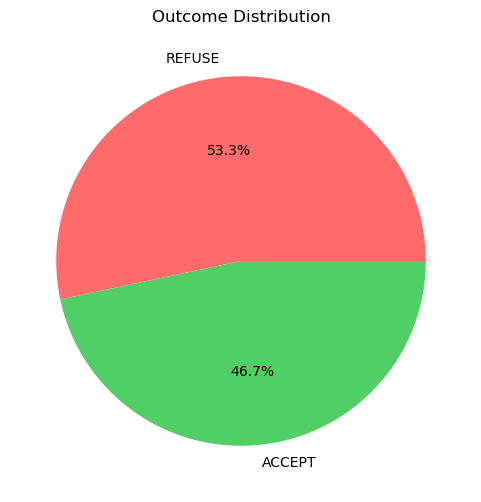

In [4]:
import matplotlib.pyplot as plt

if interventions:
    # Phân loại outcomes
    outcomes = [i['outcome'] for i in interventions]
    cumulative_correct = []
    correct = 0
    for o in outcomes:
        if o == 0:  # ACCEPT (không bị chặn) — hoặc tùy định nghĩa
            correct += 1
        cumulative_correct.append(correct / (len(cumulative_correct) + 1))
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cumulative_correct) + 1), cumulative_correct, marker='o')
    plt.xlabel('Intervention #')
    plt.ylabel('Cumulative Accuracy')
    plt.title('Accuracy over Interventions (Llama-3.1-8B)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Phân bố outcome
    num_refuse = sum(1 for o in outcomes if o == 1)
    num_accept = sum(1 for o in outcomes if o == 0)
    print(f"REFUSE: {num_refuse}, ACCEPT: {num_accept}")
    
    # Pie chart
    plt.figure(figsize=(6, 6))
    plt.pie([num_refuse, num_accept], labels=['REFUSE', 'ACCEPT'],
            autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'])
    plt.title('Outcome Distribution')
    plt.show()
else:
    print("No intervention data available")

## 4. Phân tích Transform Patterns

Transform usage:
  rot13: 2
  add_suffix: 1
  format_as_json: 1
  to_lowercase: 1
  quoted_printable: 1
  base64: 1


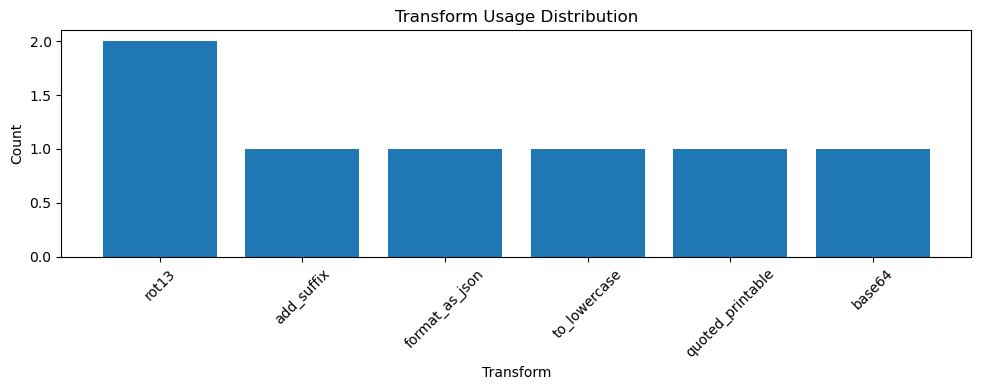

In [5]:
if interventions:
    # Thống kê các transform được sử dụng
    from collections import Counter
    transform_counts = Counter()
    for i in interventions:
        for t in i.get('transforms', []):
            if isinstance(t, dict):
                name = t.get('name', str(t))
            else:
                name = str(t)
            transform_counts[name] += 1
    
    print("Transform usage:")
    for name, count in transform_counts.most_common():
        print(f"  {name}: {count}")
    
    if transform_counts:
        plt.figure(figsize=(10, 4))
        names, counts = zip(*transform_counts.most_common())
        plt.bar(names, counts)
        plt.xlabel('Transform')
        plt.ylabel('Count')
        plt.title('Transform Usage Distribution')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("No intervention data")

## 5. Kết luận

- **Program phát hiện được**: xem cấu trúc AST ở trên
- **Accuracy**: so sánh với ground truth (nếu có)
- **Số can thiệp cần thiết**: bao nhiêu can thiệp để hội tụ
- **Độ chính xác của defense đã học**: accuracy của chương trình cuối cùng

*Phân tích này giúp hiểu Llama-3.1-8B từ chối prompt nào và bằng cơ chế gì.*